In [2]:
using LinearAlgebra
using Plots
using SparseArrays
using Polynomials
using ForwardDiff

function chebyshevT(n, x)
        if n == 0
            return one(x)
        elseif n == 1
            return x
        else
            Tnm2 = one(x)
            Tnm1 = x
            for k in 2:n
                Tn = 2*x*Tnm1 - Tnm2
                Tnm2, Tnm1 = Tnm1, Tn
            end
            return Tnm1
        end
end

function RKC_diffusion_dynamic_dt(g, a, d, D, h, T, atol, rtol)


    N = Int((d - a) / h) - 1
    x = [a + i*h for i in 1:N]
    u = g.(x)
    Lh = Tridiagonal(fill(D/h^2, N-1), fill(-2D/h^2, N), fill(D/h^2, N-1))
    τ₀ = h^2 / (4 * D)
    v = τ₀^2 * (Lh * Lh) * u
    Est₀ = sqrt(1/N * sum((v ./ (atol .+ rtol .* abs.(u))).^2))
    dt_initial = 0.1 * τ₀ / sqrt(Est₀)
    dt = dt_initial

    t = 0.0
    ϵ = 2/13

    err_old = nothing
    dt_old = nothing

    while t < T

        dt = min(dt, T - t)


        s = max(2, Int(ceil(sqrt(4 * D * dt / (h^2 * 0.653))))) # Number of stages
        w0 = 1 + ϵ / s^2

        Ts = z -> chebyshevT(s, z)
        Ts1 = ForwardDiff.derivative(Ts, w0)
        Ts2 = ForwardDiff.derivative(z -> ForwardDiff.derivative(Ts, z), w0)
        w1 = Ts1 / Ts2

        b = zeros(s+1)
        for i in 3:s+1
            Ti = z -> chebyshevT(i-1, z)
            Ti1 = ForwardDiff.derivative(Ti, w0)
            Ti2 = ForwardDiff.derivative(z -> ForwardDiff.derivative(Ti, z), w0)
            b[i] = Ti2 / Ti1^2
        end
        b[1] = b[3]
        b[2] = b[3]

        μ̃ = zeros(s+1)
        μ̃[2] = b[2] * w1
        for i in 3:s+1
            μ̃[i] = 2 * b[i] * w1 / b[i - 1]
        end

        μ = zeros(s+1)
        for i in 3:s+1
            μ[i] = 2 * b[i] * w0 / b[i - 1]
        end

        v = zeros(s+1)
        for i in 3:s+1
            v[i] = -b[i]/b[i - 2]
        end

        γ̃ = zeros(s+1)
        for i in 3:s+1
            γ̃[i] = - (1 - b[i-1] * chebyshevT(i-2, w0)) * μ̃[i]
        end

        c = zeros(s+1)
        for i in 3:s
            c[i] = (i^2 - 1)/(s^2 -1)
        end
        c[1] = c[2]/4
        c[s+1] = 1

        Y = zeros(N, s+1)
        u_old = copy(u)

        Y[:, 1] = u
        Y[:, 2] = Y[:, 1] + μ̃[2] * (Lh * Y[:, 1]) * dt

        for j in 3:s+1
            Y[:, j] .= (1 - μ[j] - v[j]) .* Y[:, 1] .+ μ[j] * Y[:, j-1] .+ v[j] * Y[:, j-2] .+ γ̃[j] * dt * (Lh * Y[:, 1])
            Y[:, j] .+= μ̃[j] * dt .* (Lh * Y[:, j-1])
        end

        u_new = Y[:, s+1]



        Est = 1/15 * (12 * (u_old - u_new) + 6 * dt * (Lh * u_old + Lh * u_new))
        Est_norm = sqrt(1/N * sum(Est.^2 ./ (atol .+ rtol .* abs.(u_new)).^2))
        if Est_norm <= 1
            t += dt
            u = copy(u_new)

            if err_old == nothing
                fac = 0.8 * Est_norm^(-1/3)
            else
                fac = 0.8 * (err_old^(-1/3)/Est_norm^(1/3)) * (dt/dt_old)/Est_norm^(1/3)
            end

            fac = clamp(fac, 0.1, 10.0)
            dt_old = dt
            err_old = Est_norm
            dt = fac * dt

        else
            fac = 0.8 * Est_norm^(-1/3)
            fac = clamp(fac, 0.1, 10.0)
            dt = fac * dt
        end

    end

    return x, u

end








RKC_diffusion_dynamic_dt (generic function with 1 method)

RKC values: [0.011708032758619289, 0.023404511102433696, 0.03507789201945088, 0.04671665529205015, 0.058309314866046166]
Exact values: [0.011707036132755203, 0.023402518834254978, 0.03507490607508568, 0.04671267861826501, 0.05830435138733814]
3.172880545887491e-5


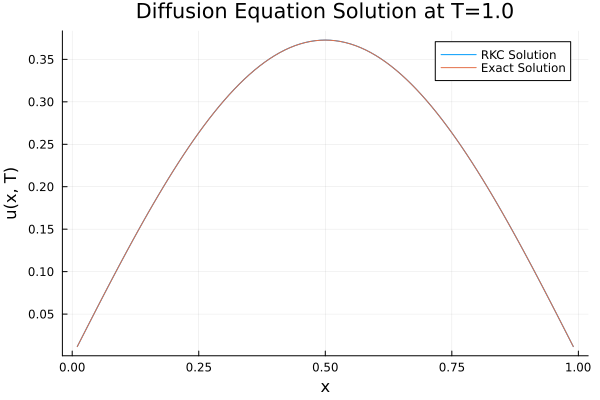

In [11]:
a = 0.0
d = 1.0
D = 0.1
h = 0.01
T = 1.0
atol = 1e-10
rtol = 1e-7
g = x -> sin(pi * x)
u_exact = x -> exp(-D * pi^2 * T) * sin(pi * x)
x, u = RKC_diffusion_dynamic_dt(g, a, d, D, h, T, atol, rtol)
println("RKC values: ", u[1:5])
println("Exact values: ", u_exact.(x)[1:5])
println(maximum(abs.(u - u_exact.(x))))
plot(x, u, label="RKC Solution", xlabel="x", ylabel="u(x, T)", title="Diffusion Equation Solution at T=1.0")
plot!(x, u_exact.(x), label="Exact Solution", xlabel="x", ylabel="u(x, T)", title="Diffusion Equation Solution at T=1.0")